In [1]:
from sklearn.metrics import mutual_info_score
from os import listdir
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy, pearsonr
#from dit import Distribution
#from dit.multivariate import coinformation
import seaborn as sns
from collections import Counter

new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
plt.rcParams.update(new_rc_params)

In [ ]:
def load_data(directory, population, var_of_interest, inhib = True):
    neural_act = []
    stim_id = []
    if inhib:
        inhib_folder = 'ScaleTH/'
    else:
        inhib_folder = 'ScaleTH/'
    lst = listdir('./neural_activity/' + inhib_folder + directory + population + var_of_interest)
    sorted_files = sorted(lst, key=lambda x: int(x.split('.')[0]))
    for f in sorted_files:
        neural_act.append(np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
        stim_id.append(Path(f).stem)
    neural_act = np.asarray(neural_act, dtype="object")
    stim_id = np.asarray(stim_id, dtype=int)
    return neural_act, stim_id

In [ ]:
def load_spiketimes(directory, population, rank):
    neural_act = []
    stim_id = []
    for f in listdir('./neural_activity_bis/ScaleTH/' + directory + population + '/spike_time'):
        sp_time = np.genfromtxt('./neural_activity_bis/ScaleTH/' + directory + population + '/spike_time' + '/' + f, delimiter=',')
        sp_time = np.unique(sp_time)[rank]
        neural_act.append(sp_time)
        stim_id.append(Path(f).stem)
    neural_act = np.asarray(neural_act)
    return neural_act, np.asarray(stim_id, dtype=int)


In [4]:
def load_spiketime_per_neuron(directory, population, populationsize, rank):
    neuron_ids, stim_id = load_data(directory, population, '/spike_id')
    neuron_sptime, _ = load_data(directory, population, '/spike_time')
    sp_time_per_neuron = np.zeros((len(stim_id), populationsize))
    for j in range(len(stim_id)):
        #sp_time_per_neuron_per_stim = []
        for i in range(populationsize):
            #sp_time_per_neuron_per_stim.append(neuron_sptime[j][np.where(neuron_ids[j] == i)])
            try:
                sp_time_per_neuron[j, i] = neuron_sptime[j][np.where(neuron_ids[j] == i)][rank]
            except:
                pass
        #sp_time_per_neuron.append(sp_time_per_neuron_per_stim)
    return sp_time_per_neuron, stim_id

In [5]:
def compute_nb_spike_per_neuron(data, popsize):
    data = np.asarray(data, dtype=int)
    spike_per_neuron = np.zeros(popsize)
    for i in np.unique(data):
        spike_per_neuron[i] = np.sum(np.where(data == i, 1, 0))

    return spike_per_neuron

C:\Users\Tansu Celikel\AppData\Local\Temp\ipykernel_33028\3829067325.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson = pearsonr(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, y])[0]#mutual_info_score(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, y])/np.log(2)


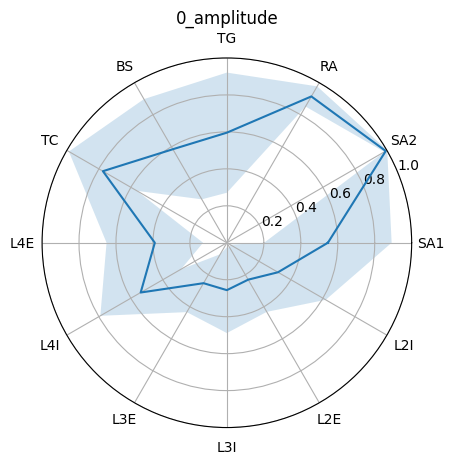

C:\Users\Tansu Celikel\AppData\Local\Temp\ipykernel_33028\3829067325.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson = pearsonr(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, y])[0]#mutual_info_score(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, y])/np.log(2)


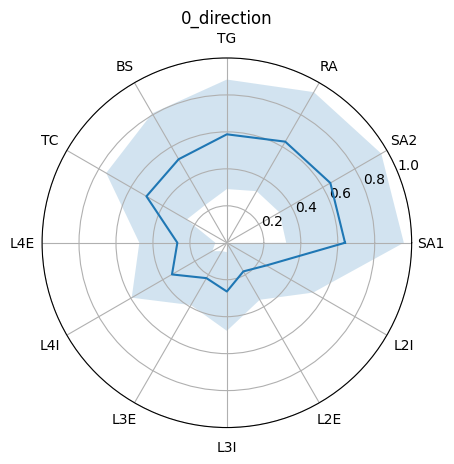

C:\Users\Tansu Celikel\AppData\Local\Temp\ipykernel_33028\3829067325.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson = pearsonr(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, y])[0]#mutual_info_score(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, y])/np.log(2)
C:\Users\Tansu Celikel\AppData\Local\Temp\ipykernel_33028\3314874382.py:11: UserWarning: genfromtxt: Empty input file: "./neural_activity_bis/ScaleTH/0_distance_to_basis/SA2/spike_id/19.csv"
  neural_act.append(np.genfromtxt('./neural_activity_bis/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))


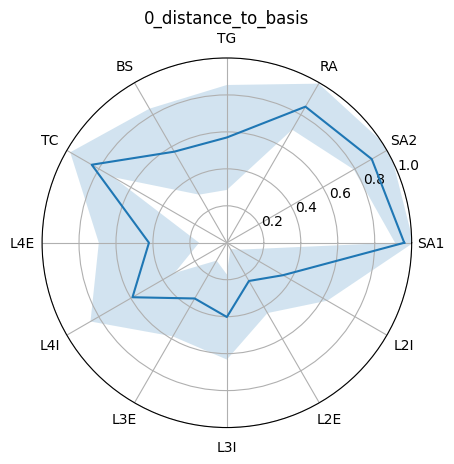

C:\Users\Tansu Celikel\AppData\Local\Temp\ipykernel_33028\3829067325.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson = pearsonr(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, y])[0]#mutual_info_score(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, y])/np.log(2)
C:\Users\Tansu Celikel\AppData\Local\Temp\ipykernel_33028\3829067325.py:30: RuntimeWarning: Mean of empty slice.
  if np.isnan(correlation_per_neuron.mean()):
C:\Users\Tansu Celikel\AppData\Roaming\Python\Python313\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\Tansu Celikel\AppData\Local\Temp\ipykernel_33028\3314874382.py:11: UserWarning: genfromtxt: Empty input file: "./neural_activity_bis/ScaleTH/0_frequency/SA2/spike_id/2.csv"
  neural_act.append(np.genfromtxt('./neural_activity_bis/' + inhib_folder + directory + popula

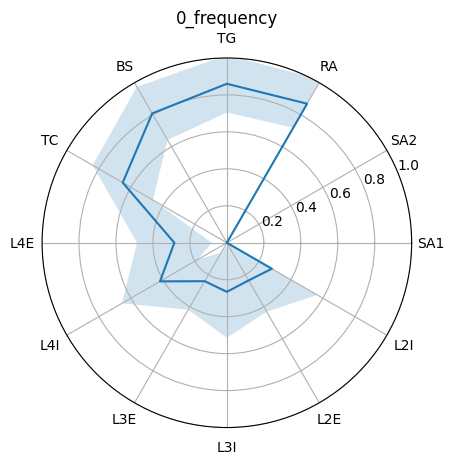

C:\Users\Tansu Celikel\AppData\Local\Temp\ipykernel_33028\3829067325.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson = pearsonr(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, y])[0]#mutual_info_score(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, y])/np.log(2)


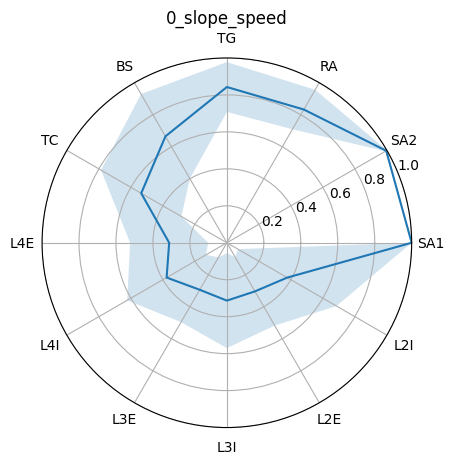

In [6]:
Parameters = ['0_amplitude', '0_direction', '0_distance_to_basis', '0_frequency', '0_slope_speed']
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS', 'TC', 'L4E', 'L4I', 'L3E', 'L3I', 'L2E', 'L2I']
Populations_sizes = [24, 10, 36, 70, 70, 70, 188, 33, 158, 28, 86, 15]
for param in Parameters:
    correlation_per_neuron_per_pop_mean = []
    correlation_per_neuron_per_pop_std = []
    for j in range(len(Populations)):
        correlation_per_neuron = []
        popsize = Populations_sizes[j]
        neural_act, stim_id = load_data(param, '/' + Populations[j], '/spike_id')
        spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
        for i in range(len(spike_per_neuron_per_stimulus)):
            spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
        co_inf = np.zeros((popsize, popsize))
        for i in range(popsize):
            for y in range(popsize):
                #if np.unique(spike_per_neuron_per_stimulus[:, i]) != 0 and np.unique(spike_per_neuron_per_stimulus[:, y]) != 0:
                pearson = pearsonr(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, y])[0]#mutual_info_score(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, y])/np.log(2)
                #print(spike_per_neuron_per_stimulus[:, j])
                #if (not np.isnan(pearson)) and (pearson != 0) and not(np.isclose(pearson, 0, atol=1e-10)):
                if np.isnan(pearson):
                    pearson=0
                correlation_per_neuron.append(pearson)
        #    for k in range(popsize):
        #        co_inf[i, k] = co_information(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, k], stim_id)
        #sns.heatmap(co_inf)
        #plt.show()
        correlation_per_neuron = np.asarray(correlation_per_neuron)
        correlation_per_neuron = correlation_per_neuron[correlation_per_neuron > 0]
        if np.isnan(correlation_per_neuron.mean()):
            mean = 0
            std = 0
        else:
            mean = correlation_per_neuron.mean()
            std = correlation_per_neuron.std()
        correlation_per_neuron_per_pop_mean.append(mean)
        correlation_per_neuron_per_pop_std.append(std)
        #plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    coord = np.deg2rad(np.linspace(0, 360, num=13, dtype=int))
    correlation_per_neuron_per_pop_mean.append(correlation_per_neuron_per_pop_mean[0])
    ax.plot(coord, np.asarray(correlation_per_neuron_per_pop_mean))
    ax.set_xticks(coord[:-1])
    ax.set_xticklabels(['SA1', 'SA2', 'RA', 'TG', 'BS', 'TC', 'L4E', 'L4I', 'L3E', 'L3I', 'L2E', 'L2I'])
    correlation_per_neuron_per_pop_std.append(correlation_per_neuron_per_pop_std[0])
    std_plus = np.asarray(correlation_per_neuron_per_pop_mean) + np.asarray(correlation_per_neuron_per_pop_std)
    std_minus = np.asarray(correlation_per_neuron_per_pop_mean) - np.asarray(correlation_per_neuron_per_pop_std)
    ax.fill_between(coord, std_plus, std_minus, alpha=0.2)
    ax.set_title(param)
    ax.set_ylim(0, 1)
    #ax.plot(coord, , linestyle='dashed')
    #ax.plot(coord, , linestyle='dashed')
    #plt.violinplot(correlation_per_neuron_per_pop)    
    #plt.xticks(np.arange(1,6), Populations)
    plt.savefig('./Figures/Correlation/Pearson_bis' + param + '.svg')
    plt.show()